In [1]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import pandas as pd

import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import numpy as np


from enum import Enum

In [2]:
class DataSet(Enum):
    ONE = 1
    TWO = 2
    THREE = 3
    FOUR = 4
    FIVE = 5
    SIX = 6
    SEVEN = 7
    EIGHT = 8

data_set = DataSet.FIVE;

class AquisitionFunction(Enum):
    UCB = 1


In [3]:

#Load initial data
match data_set:
    case DataSet.ONE:
        X = np.load("initial_data/function_1/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_1/initial_outputs.npy"))

        X = np.append(X, [[0.811933, 0.784473],\
                          [0.760428, 0.740481],\
                          [0.883211, 0.8579],\
                        [0.677879, 0.765321]], 0)
        
        y = np.append(y, [5.357376e-41,\
                          -3.988358448527149e-22,\
                          3.346982715934273e-82,\
                         -1.0963705404916755e-15])
        
        print(X.shape)
        print(y.shape)
    case DataSet.TWO:
        X = np.load("initial_data/function_2/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_2/initial_outputs.npy"))

        X = np.append(X, [[0.818082, 0.926635],\
                          [0.629435, 0.979317],\
                          [0.658187, 0.220649],\
                         [0.658187, 0.220649]],0)
        
        y = np.append(y, [-0.02537857,\
                          0.16695424310575757,\
                          0.3342521887135788,\
                         0.32976597238596456])
        
        print(X.shape)
        print(y.shape)
    case DataSet.THREE:
        X = np.load("initial_data/function_3/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_3/initial_outputs.npy"))

        X = np.append(X, [[0.486552, 0.999089, 0.997841],\
                          [0.488571, 0.658352, 0.181652],\
                          [0.192268, 0.359652, 0.480198],\
                         [0.279340, 0.263244, 0.487525]], 0)
        
        y = np.append(y, [-0.48078736,\
                          -0.11867972718508736,\
                          -0.015124747528271847,\
                         -0.033627475132407686])
        print(X)
        print(X.shape)
        print(y.shape)
    case DataSet.FOUR:
        X = np.load("initial_data/function_4/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_4/initial_outputs.npy"))

        X = np.append(X, [[0.004832, 0.382262, 0.921803, 0.990838],\
                          [0.489871, 0.449092, 0.426088, 0.200254],\
                          [0.443021, 0.43593, 0.46009, 0.165955],\
                         [0.437929, 0.487365, 0.464366, 0.162047]], 0)
        
        y = np.append(y, [-32.284832,\
                          -4.01093378167592,\
                          -4.038551362294328,\
                         -4.906573615106581])
        
        print(X.shape)
        print(y.shape)
    case DataSet.FIVE:
        X = np.load("initial_data/function_5/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_5/initial_outputs.npy"))


        X = np.append(X, [[0.212855, 0.844288, 0.880739, 0.871421],\
                          [0.250910, 0.847168, 0.810841, 0.888456],\
                          [0.234228, 0.842623, 0.869035, 0.866812],\
                         [0.203519, 0.858293, 0.866535, 0.871801]], 0)
        
        y = np.append(y, [1052.113900,\
                          867.4163870739638,\
                          975.003291464923,\
                         1047.5787601018394])
        
        print(X.shape)
        print(y.shape)
    case DataSet.SIX:
        X = np.load("initial_data/function_6/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_6/initial_outputs.npy"))


        X = np.append(X, [[0.023802, 0.008308, 0.294059, 0.011586, 0.015609],\
                          [0.660835, 0.200569, 0.706006, 0.709946, 0.078452],\
                          [0.641711, 0.172321, 0.744614, 0.703486, 0.012136],\
                         	[0.669229, 0.135194, 0.704419, 0.773126, 0.029229]], 0)
        
        y = np.append(y, [-2.014607,\
                          -0.5747952680603831,\
                          -0.5988774103947822,\
                         -0.5232915167212367])
        
        print(X.shape)
        print(y.shape)
    case DataSet.SEVEN:
        X = np.load("initial_data/function_7/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_7/initial_outputs.npy"))

        X = np.append(X, [[0.104168, 0.456114, 0.256427, 0.215101, 0.372639, 0.722473],\
                          [0.159087, 0.468380, 0.250022, 0.224439, 0.388239, 0.733159],\
                          [0.148587, 0.499419, 0.292025, 0.213570, 0.358445, 0.692945],\
                         [0.101903, 0.497851, 0.256241, 0.188197, 0.318147, 0.720967]], 0)
        
        y = np.append(y, [1.796145391,\
                          1.731309761735286,\
                          1.8020727553514053,\
                         1.672162883714266])
        
        print(X.shape)
        print(y.shape)
    case DataSet.EIGHT:
        X = np.load("initial_data/function_8/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_8/initial_outputs.npy"))

        X = np.append(X, [[0.345531, 0.274921, 0.707992, 0.654609, 0.742221, 0.787590, 0.240555, 0.887229],\
                          [0.038099, 0.066224, 0.055483, 0.121707, 0.389464, 0.807509, 0.402120, 0.958319],\
                          [0.032520, 0.049536, 0.048605, 0.092144, 0.462876, 0.837723, 0.453185, 0.952651],\
                         [0.012842, 0.027512, 0.154929, 0.070592, 0.397277, 0.828666, 0.484246, 0.857103]], 0)
        
        y = np.append(y, [8.5110526203,\
                          9.6944833424009,\
                          9.6460524474459,\
                         9.6043176411276])
        
        print(X.shape)
        print(y.shape)
    case _:
        print('No data set found')

(23, 4)
(23,)


In [4]:
# Week 1 General Code
def MakePrediction(X, y, noise_assumption,rbf_lengthscale, beta, n_samples, AF):
    # Define Model
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    #Sclae y data, x is already constrained
    scaler = sk.preprocessing.StandardScaler();

    scaler.fit(y.reshape(-1,1));
    y = scaler.transform(y.reshape(-1,1));
    
    # Fit Model
    model.fit(X, y)

    n_features = X.shape[1]

    # Create Sample points for aquisition funciton
    x_s = np.random.rand(n_samples, n_features);
    
    post_mean, post_std = model.predict(x_s, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    if AF == AquisitionFunction.UCB:
        aquisition_function = post_mean + beta * post_std

    print("Aquisition function Max:", aquisition_function.max())
    print("Aquisition function Min:", aquisition_function.min())
    
    index = aquisition_function.argmax();

    return x_s[index,:]


In [10]:
#@tf.function
def forward_pass(x):
    bias = tf.ones((tf.shape(x)[0], 1))
    x_with_bias = tf.concat([x, bias], axis=1)
    hidden_linear = tf.matmul(x_with_bias, W1)
    hidden_relu = tf.nn.relu(hidden_linear)
    output_linear = tf.matmul(hidden_relu, W2)
    output_sigmoid = tf.sigmoid(output_linear)
    return output_sigmoid

In [6]:
#@tf.function
def train_step(x,y):
    with tf.GradientTape() as tape:
        y_pred = forward_pass(x)
        loss = loss_fn(y, y_pred)
    gradients = tape.gradient(loss, [W1, W2])
    optimizer.apply_gradients(zip(gradients, [W1, W2]))
    return loss

In [7]:
# Week 1 General Code
def MakePredictionCNN(X, y):
    # Define Model

    X = np.float32(X);
    y = np.float32(y);
  
    y = scaler.transform(y.reshape(-1,1));
    
    for epoch in range(1000):
        loss = train_step(X,y)
        if np.mod(epoch, 100) == False:
            print(loss)
        if epoch == 0:
            print(loss)

    print(loss);
    return loss;


In [8]:
def display_basic_stats(X, y, x_next):

    # Calc general stat of dataset
    
    mean_y = y.mean();
    std_y = y.std();

    max_y = y.max();
    min_y = y.min();

    max_pVal = (max_y - mean_y)/std_y;
    min_pVal = (mean_y-min_y)/std_y;

    print("Mean and Std of Y: ", mean_y, ", ", std_y)
    print("Max and min of Y: ", max_y, ", ", min_y)
    print("Max and Min P-Val: ", max_pVal, ", ", min_pVal)


    # Calc stas of each point
    
    order = np.flip(np.argsort(y,0)).flatten();
    
    max_y_ind = order[0];
    min_y_ind = order[-1];

    nf = X.shape[0];

    stats_raw = [];
    
    for i in range(nf):
        Index = order[i];
        Y = y[Index]
        Y_Rank = i+1;
        Max_ED = np.linalg.norm(X[Index,:]-X[max_y_ind,:])
        Max_YD = y[max_y_ind]-y[Index]
        Min_ED = np.linalg.norm(X[Index,:]-X[min_y_ind,:])
        Min_YD = y[min_y_ind]-y[Index]
        pVal = (y[Index]-mean_y)/std_y
        stats_raw.append([Index, Y, Y_Rank, Max_ED, Max_YD, Min_ED, Min_YD, pVal]);
    
    headings = ['Index', 'Y', 'Y-Rank', 'Max-Euclid-Dist', 'Max-Y-Delta', 'Min-Euclid-Dist', 'Min-Y-Delta', 'Z-Score']
    stats = pd.DataFrame(stats_raw, columns = headings)
    print(stats)

    # Calc Stats of new point
    
    dist = np.linalg.norm(X - x_next, axis=1);
    order_n = np.argsort(dist,0)
    
    stats_new = []
    
    for i in range(nf):
        Index = order_n[i];
        Y = y[Index];
        Y_rank = np.where(order==Index)[0]
        Dist = dist[Index]
        stats_new.append([Index, Y, Y_rank, Dist])

    headings = ['Index', 'Y', 'Y-Rank', 'Dist']
    stats = pd.DataFrame(stats_new, columns = headings)
    print(stats)


Aquisition function Max: 2.01178712388386
Aquisition function Min: 1.9952928506550687
<tf.Variable 'Variable:0' shape=(5, 10) dtype=float32, numpy=
array([[-0.24167365,  0.73938394, -0.55005854,  0.12856545, -0.4245098 ,
        -0.07821264, -0.01220349,  1.0212588 ,  0.84510195,  0.4585193 ],
       [ 1.35911   , -1.2418698 , -0.58875495, -1.09366   ,  0.38285533,
         0.24720353, -0.87144285, -1.5673645 ,  0.4659226 ,  0.19508778],
       [ 1.1649092 ,  0.3254994 , -0.93521565,  0.76547503, -2.1526082 ,
         1.0504241 , -0.36433646, -0.09338038, -0.00408831, -1.5241781 ],
       [-0.27314955,  1.5827621 ,  0.13232107, -0.49902445,  0.7616978 ,
         0.74454516, -1.1007596 , -0.5675348 ,  0.14603162,  0.3682595 ],
       [-0.37606883, -0.9754525 , -0.11539682,  0.6805943 ,  2.8610005 ,
        -0.24346277,  0.6906153 ,  1.8924284 , -1.0127279 , -0.37732562]],
      dtype=float32)>
<tf.Variable 'Variable:0' shape=(10, 1) dtype=float32, numpy=
array([[-0.8538066 ],
       [-0

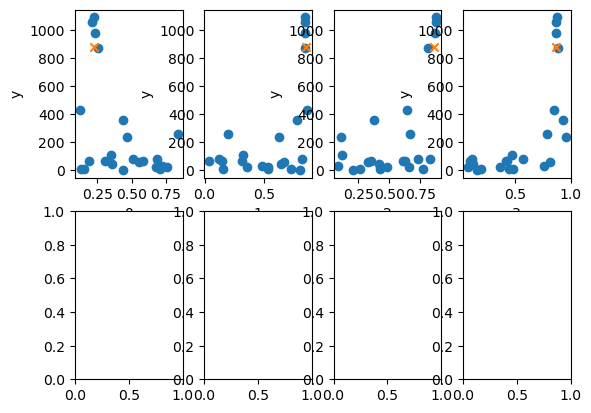

In [16]:
#Cell for processing dataset 1

noise_assumption = 1e-10;
rbf_lengthscale = 0.1;
beta = 2;
n_samples = 1000000;

Learning_rate = 0.1;

AF = AquisitionFunction.UCB

# Pre Processing if required

if data_set == DataSet.ONE:
    inliers = y > 0;
    X2 = X;
    y2 = y;
    y2[inliers] = y[inliers];
    y2[~inliers] = y[inliers].min();
    y2 = np.log(y2);
    beta = 0;
    noise_assumption = 1e-5;
    rbf_lengthscale = 0.1;
if data_set == DataSet.EIGHT:
    X2 = X;
    y2 = y;
    noise_assumption = y2.std()/4;
else:
    X2 = X;
    y2 = y;
    noise_assumption = y2.std();

x_next = MakePrediction(X2,y2,noise_assumption,rbf_lengthscale, beta, n_samples, AF)

#CNN stuff
nF = X2.shape[1];
nW = 10; #int(np.floor(nF/2));

# define weights for first layer


W1 = tf.random.normal(shape=(nF+1,nW), mean=0, stddev=1);
W1 = tf.Variable(W1);

# weight for output layer
W2 = tf.random.normal(shape=(nW, 1), mean=0, stddev=1);
W2 = tf.Variable(W2);

# loss function and 
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.optimizers.SGD(learning_rate=Learning_rate)



scaler = sk.preprocessing.MinMaxScaler(feature_range=(0.1,0.9));
scaler.fit(y.reshape(-1,1));

print(W1)
print(W2)
loss = MakePredictionCNN(X2,y2)
print(W1)
print(W2)
#x_next = np.array([0.5,0.5,0.5,0.5])

x_nexttem = np.float32(x_next.reshape(-1,1)).T;
y_pred = forward_pass(x_nexttem);
y_pred = scaler.inverse_transform(y_pred);


display_basic_stats(X2, y2, x_next)

nF = X.shape[1];

fig, subs = plt.subplots(2,4);


# plot 1 dimensional distribution
for i in range(nF):
    row = int(np.floor(i/4));
    col = int(np.mod(i,4));
    subs[row][col].scatter(X2[:, i], y2, marker='o');
    subs[row][col].set(ylabel = 'y');
    subs[row][col].set(xlabel = i);
    subs[row][col].scatter(x_next[i], y_pred, marker='x');


print(x_next);
print(y_pred);
# print prediction
for i in range(nF):
    nD = "{:.6f}".format(x_next[i])
    print("Element: ", i, ", Value=", nD)

    